# Introdução

## Contexto

Você recebeu uma tarefa analítica de uma loja online internacional. Seu predecessor não conseguiu completá-la: ele lançou um teste A/B e depois desistiu (para começar uma fazenda de melancias no Tocantins). 
Ele deixou apenas as especificações técnicas e resultado dos testes.

Descrição técnica:
* Nome do teste: recommender_system_test
* Grupos: A (controle) e B (funil de novos pagamentos)
* Data de início: 07-12-2020
* Quando paparam de receber novos usuários: 21-12-2020
* Data de término: 01-01-2021
* Público: 15% de novos usuários da região da UE
* Propósito do teste: testar mudanças relacionadas à introdução de um sistema de recomendação melhorado
* Resultado esperado: em até 14 dias após o cadastro, usuários mostram uma conversão melhor nas visualizações de página do produto (o evento product_page event), em adicionar itens ao carrinho (product_cart) e de compras (purchase). Em cada etapa do funil product_page → product_cart → purchase, haverá ao menos 10% de aumento.
* Número esperado de participantes do teste: 6000

## Dados

Datasets que serão utilizados para análise e suas descrições:

'ab_project_marketing_events_us.csv' —> o calendário de eventos de marketing para 2020

'final_ab_new_users_upd_us.csv' —> todos os usuários que se cadastraram na loja online de 7 a 21 de dezembro de 2020

'final_ab_events_upd_us.csv' —> todos os eventos dos novos usuários dentro do período de 7 de dezembro de 2020 até 1 de janeiro de 2021

'final_ab_participants_upd_us.csv' —> tabela contendo os participantes do teste

Estrutura do dataset 'ab_project__marketing_events_us.csv':

* name — nome dos eventos de marketing
* regions — regiões onde a campanha será realizada
* start_dt — data de início da campanha
* finish_dt — data de término da campanha

Estrutura do dataset 'final_ab_new_users_upd_us.csv':

* user_id
* first_date — data de cadastro
* region
* device — dispositivo usado para o cadastro

Estrutura do dataset 'final_ab_events_upd_us.csv':

* user_id
* event_dt — data e hora do evento
* event_name — nome da fonte do evento
* details — dados adicionais sobre o evento (por exemplo, o total do pedido em USD para eventos purchase)

Estrutura do dataset 'final_ab_participants_upd_us.csv':

* user_id
* ab_test — nome do teste
* group — o grupo de teste ao qual o usuário pertencia

## Objetivo

# Setup e Dados

## Ambiente

### Importação de bibliotecas

In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import numpy as np
import scipy

### Configurações globais

In [3]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### Carregamento de dados

In [4]:
marketing = pd.read_csv('../datasets/ab_project_marketing_events_us.csv')

In [5]:
events = pd.read_csv('../datasets/final_ab_events_upd_us.csv')

In [6]:
users = pd.read_csv('../datasets/final_ab_new_users_upd_us.csv')

In [7]:
participants = pd.read_csv('../datasets/final_ab_participants_upd_us.csv')

## Pré Processamento

### Primeiras impressões

In [8]:
marketing.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [9]:
marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes


In [10]:
marketing.describe()

,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Christmas&New Year Promo,APAC,2020-12-25,2021-01-03
freq,1,4,1,1


In [11]:
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [12]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  str    
 1   event_dt    423761 non-null  str    
 2   event_name  423761 non-null  str    
 3   details     60314 non-null   float64
dtypes: float64(1), str(3)
memory usage: 12.9 MB


In [13]:
events.describe()

,details
count,60314.00
mean,23.88
std,72.23
min,4.99
25%,4.99
50%,4.99
75%,9.99
max,499.99


In [14]:
users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [15]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     58703 non-null  str  
 1   first_date  58703 non-null  str  
 2   region      58703 non-null  str  
 3   device      58703 non-null  str  
dtypes: str(4)
memory usage: 1.8 MB


In [16]:
users.describe()

,user_id,first_date,region,device
count,58703,58703,58703,58703
unique,58703,17,4,4
top,D72A72121175D8BE,2020-12-21,EU,Android
freq,1,6077,43396,26159


In [17]:
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [18]:
participants.info()

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
dtypes: str(3)
memory usage: 340.6 KB


In [19]:
participants.describe()

,user_id,group,ab_test
count,14525,14525,14525
unique,13638,2,2
top,DABC14FDDFADD29E,A,interface_eu_test
freq,2,8214,10850


Foi constatada a presença de valores nulos no dataframe 'events' (coluna details). Em todos os dataframes, as colunas seguem o padrão snake_case. Há necessidade de ajuste do tipo de dado das colunas temporais.

### Valores duplicados

In [20]:
marketing.duplicated().sum()

np.int64(0)

In [21]:
events.duplicated().sum()

np.int64(0)

In [22]:
users.duplicated().sum()

np.int64(0)

In [23]:
participants.duplicated().sum()

np.int64(0)

Não foram encontrados registros duplicados.

### Valores nulos
 

In [24]:
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [25]:
events['event_name'].value_counts()

event_name
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: count, dtype: int64

É compreensível a presença de valores ausentes na coluna detais, logo que foram preenchidos registros em que event_name == purchase, referindo-se ao valor de uma compra.

### Ajuste tipos de dado

In [26]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])

In [27]:
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

In [28]:
events['event_dt'] = pd.to_datetime(events['event_dt'])

In [29]:
users['first_date'] = pd.to_datetime(users['first_date'])

### Engenharia de características

In [30]:
# criação dataframe agregado 
events_agg = events.merge(participants[['user_id','group']], on='user_id')

In [31]:
# desenvolvimento dataframe agregado
events_agg = events_agg.merge(users, on='user_id')

In [32]:
# criação coluna day
events_agg['day'] = events_agg['event_dt'].dt.day

In [33]:
# criação coluna week
events_agg['week'] = events_agg['event_dt'].dt.isocalendar().week

In [34]:
# criação função para criação coluna is_event
def is_event(row):
    if (row['region'] == 'EU' or 'NA') and (24 < row['day'] < 31):
        return True
    elif (row['region'] == 'CIS') and (row['day'] == 30):
        return True
    else:
        return False

In [35]:
# aplicação função
events_agg['is_event'] = events_agg.apply(is_event, axis=1)

In [36]:
events_agg.head()

,user_id,event_dt,event_name,details,group,first_date,region,device,day,week,is_event
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B,2020-12-07,EU,iPhone,7,50,False
1,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,2020-12-07,EU,Android,7,50,False
2,A92195E3CFB83DBD,2020-12-07 00:32:07,purchase,4.99,A,2020-12-07,EU,Android,7,50,False
3,354D653172FF2A2D,2020-12-07 15:45:11,purchase,4.99,A,2020-12-07,EU,Mac,7,50,False
4,7FCD34F47C13A9AC,2020-12-07 22:06:13,purchase,9.99,B,2020-12-07,EU,PC,7,50,False


# EDA

In [37]:
events_agg.head()

,user_id,event_dt,event_name,details,group,first_date,region,device,day,week,is_event
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B,2020-12-07,EU,iPhone,7,50,False
1,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,2020-12-07,EU,Android,7,50,False
2,A92195E3CFB83DBD,2020-12-07 00:32:07,purchase,4.99,A,2020-12-07,EU,Android,7,50,False
3,354D653172FF2A2D,2020-12-07 15:45:11,purchase,4.99,A,2020-12-07,EU,Mac,7,50,False
4,7FCD34F47C13A9AC,2020-12-07 22:06:13,purchase,9.99,B,2020-12-07,EU,PC,7,50,False


In [38]:
events_agg['event_name'].value_counts()

event_name
login           44705
product_page    28961
purchase        14854
product_cart    14318
Name: count, dtype: int64

## Taxa de conversão

## Receita 

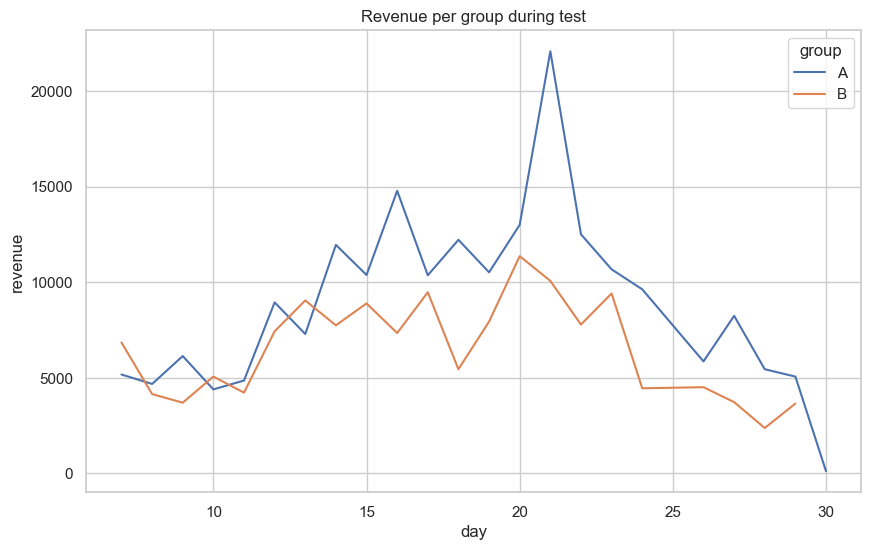

Receita total do grupo A durante o período de testes: $204443.81
Receita total do grupo B durante o período de testes: $144762.65


In [44]:
# criação gráfico de linha
sns.lineplot(data=events_agg[events_agg['event_name'] == 'purchase'].groupby(['day', 'group'])['details'].sum().reset_index(), x='day', y='details', hue='group')
plt.title('Revenue per group during test')
plt.ylabel('revenue')
plt.show()

print(f"Receita total do grupo A durante o período de testes: ${events_agg[(events_agg['event_name'] == 'purchase') & (events_agg['group'] == 'A')]['details'].sum():.2f}")
print(f"Receita total do grupo B durante o período de testes: ${events_agg[(events_agg['event_name'] == 'purchase') & (events_agg['group'] == 'B')]['details'].sum():.2f}")

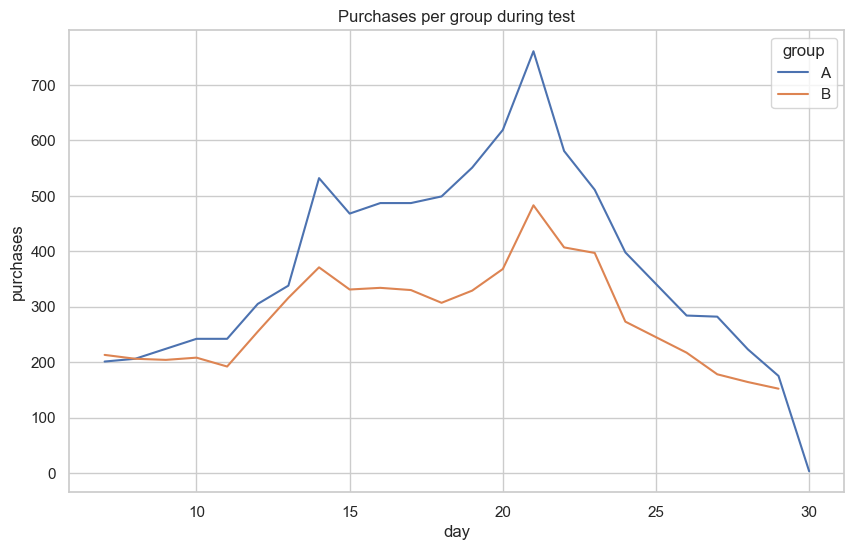

Número de compras total do grupo A durante o período de testes: 8619
Número de compras total do grupo B durante o período de testes: 6235


In [45]:
sns.lineplot(data=events_agg[events_agg['event_name'] == 'purchase'].groupby(['day', 'group'])['event_name'].count().reset_index(), x='day', y='event_name', hue='group')
plt.title('Purchases per group during test')
plt.ylabel('purchases')
plt.show()

print(f"Número de compras total do grupo A durante o período de testes: {events_agg[(events_agg['event_name'] == 'purchase') & (events_agg['group'] == 'A')]['event_name'].count()}")
print(f"Número de compras total do grupo B durante o período de testes: {events_agg[(events_agg['event_name'] == 'purchase') & (events_agg['group'] == 'B')]['event_name'].count()}")

# Conclusões e Recomendações de Negócios